# Setup

In [1]:
%%capture --no-stderr
%pip install --quiet -U langgraph langchain_openai langchain_community langchain_core tavily-python wikipedia

In [3]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("OPENAI_API_KEY")

In [4]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="gpt-5-nano", temperature=0) 

In [6]:
_set_env("LANGSMITH_API_KEY")
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"] = "langchain-academy"

In [8]:
_set_env("TAVILY_API_KEY")

# Planning

In [9]:
from pydantic import BaseModel, Field
from typing import Optional

class Analyst_schema(BaseModel):
    name: Optional[str] = Field(description= 'Name of the analyst', default = None)
    
    pointers_for_interview: list[str] = Field(description = 'Pointers to keep in mind while interviewing an expert.' ,
                                            default = """please respond with 'Thank you for taking time for this interview.' 
                                            Whenever you feel satisfied with the conversation/interview.""") 
    
    skills: list[str] = Field(description = """What are the current skills of the analyst with which we are assuming it to be eligible
    to conduct the interview.""", default_factory = list)
    
    affiliation: str = Field(description = """What is the role with which the analyst is currently associated with 
    like wether it is a department head of it's own company, CEO, Doctor, or a professor,
    or a student or something similar.""", default_factory = str)
    
    experience: str = Field(description = 'Description of the experience of the analyst.', default_factory = str)
    
    responsibility: str = Field(description = """ What are the responsibilities for the analyst for the interview,
    maybe research about more than one topic? """, default_factory = str)

In [10]:
class Analyst_collection(BaseModel): 
    interviewers: list[Analyst_schema] = Field(description = 'List of all the analysts who will be conducting the interview.')

In [11]:
# check for literals in node outputs

from langgraph.graph import MessagesState, StateGraph, START, END
from langchain.chat_models import init_chat_model
from langchain.messages import HumanMessage, SystemMessage, AIMessage

model = init_chat_model(
    model= 'gpt-5-nano',
    temperature = 0.5
)

class UserSideInput(MessagesState):
    interviewers: list[Analyst_schema]
    topic: str
    human_feedback: bool = True
    max_analysts: int
    sources : list[str]
    
# sub_topic generator and structuring the user_input node is outside the sub-graph of the analyst generator

class structured_input(BaseModel):
    topic: str
    human_feedback: bool = True
    max_analysts: int
    sources : list[str]

STRUCTURED_INPUT_message = """ Please take the following messages as input and give out a structured output: """

def input_structuring_node(state: UserSideInput):
    messages = state['messages']
    model_invokation_message = [SystemMessage(STRUCTURED_INPUT_message)] + messages
    response = model.with_structured_output(structured_input).invoke(model_invokation_message)
    model_message = [AIMessage(content='Updated the structure of the input for the given messages!')]
    return {'topic': response.topic,
            'human_feedback': response.human_feedback,
            'max_analysts' : response.max_analysts ,
            'messages': model_message,
           'sources': response.sources} 

    
ANALYST_CREATOR_PROMPT = """You are tasked to generate a list of deep analysts based on the provided schema, keep in mind that these analysts
will be responsible for conducting interviews with experts in their own sub-domains and you have to make sure that while you are adhering to the 
schema you provide as much details as possible in that. You have to return with atleast 3 analysts which have 80% distinguished sub_domains
and you are not allowed to return empty handed. Appropriate information to be generated has been provided as a structured output to you
and you can also fill in the responsibilities field in the schema with appropriate details along with the pointers.
The maximum_number of analysts you can generate is: {max_analysts_number}
The topic for which you have to create analysts for is {topic}
"""
    
def analyst_creator(state: UserSideInput):
    """ Given a user input schema this function invokes a LLM to generate a list of analyst to conduct specialized interviews"""
     # the last message will be a system message from the input or human_feedback node
    final_system_message = [SystemMessage(content = ANALYST_CREATOR_PROMPT.format(max_analysts_number = state['max_analysts'], 
                                                                                  topic = state['topic']))]
    
    response  = model.with_structured_output(Analyst_collection).invoke(final_system_message) 
    
    return {'interviewers': response,
            'messages': [AIMessage(content = 'A list of analyst has been generated successfully!')]}

def print_analysts(analysts: list[Analyst_schema], topic: str):
     
    print("""<------Following is a list of analyst generated so far!------>
        <------Topic: {topic}---------------------------------------->""".format(topic = topic))
    for i in range(len(analysts.interviewers)):
        print(
            """ 
            ******************************************
            
            Analyst Number: {analyst_index}
            Analyst Name: {analyst_name}
            
            Pointers for interview: {analyst_pointers_for_interview}
            Skills: {analyst_skills}
            
            Affiliation: {analyst_affiliation}
            Experience: {analyst_experience}

            Responsibility: {analyst_responsibility}
            
            ******************************************
            """.format(analyst_index = int(i+1), 
                       analyst_name = analysts.interviewers[i].name,
                      analyst_pointers_for_interview = analysts.interviewers[i].pointers_for_interview,
                      analyst_skills = analysts.interviewers[i].skills,
                      analyst_affiliation = analysts.interviewers[i].affiliation,
                      analyst_experience = analysts.interviewers[i].experience,
                      analyst_responsibility = analysts.interviewers[i].responsibility)
        )

def HITL(state: UserSideInput):
        
    print_analysts(analysts = state['interviewers'], topic = state['topic'])

    next_step = input("""You can either choose to continue to interview process by sending 'continue' or ask the 
    model to revise the list by sending 'revise': """)
    next_step = next_step.strip().lower()
        
    assert next_step == 'continue' or next_step == 'revise', \
    'Please check your input, only revise or continue are allowed as input'
        
    if next_step == 'continue':
        return {'messages': [SystemMessage(content = 'User feels satisfied with the list please continue to interview process.')],
               'human_feedback': False}

    if next_step == 'revise':
        return {'messages': [SystemMessage(content = 'Revision of analysts is required!.')], 
                'human_feedback': True}

def conditional_edge_HITL(state: UserSideInput):
    if state['human_feedback']:
        return 'analyst_creator'
    else:
        print("""<-------Moving onto the interviewing process now!------------->""")
        return END

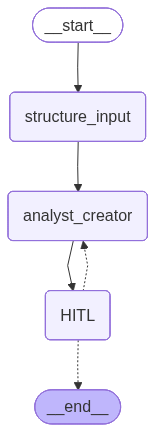

In [12]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver

analyst_graph = StateGraph(UserSideInput)

analyst_graph.add_node('structure_input', input_structuring_node)
analyst_graph.add_node('analyst_creator', analyst_creator)
analyst_graph.add_node('HITL', HITL)

analyst_graph.add_edge(START, 'structure_input')
analyst_graph.add_edge('structure_input', 'analyst_creator')
analyst_graph.add_edge('analyst_creator', 'HITL')

analyst_graph.add_conditional_edges('HITL', conditional_edge_HITL, ['analyst_creator', END])


within_thread_memory = InMemorySaver()

graph = analyst_graph.compile(checkpointer= within_thread_memory)

display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [22]:
config = {'configurable': {'thread_id': '1'}}
graph.invoke(input = {'messages':[HumanMessage(content = 'Hey I want you to create me 4 assistants that research AI automation')]}, 
            config=config)

Failed to multipart ingest runs: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


<------Following is a list of analyst generated so far!------>
        <------Topic: AI automation---------------------------------------->
 
            ******************************************

            Analyst Number: 1
            Analyst Name: Meera Kapoor

            Pointers for interview: ['Assess how RPA and LLM-driven automation are integrated into end-to-end workflows.', 'Explore governance, risk, and compliance considerations in AI-enabled automation programs.', 'Ask for evidence of ROI, cycle time reduction, error rate improvements, and maintenance cost.', 'Investigate change management, workforce impact, and upskilling strategies.', 'Request case studies across manufacturing and services.', 'Probe interoperability with existing IT/OT systems and data lineage.', 'Identify success metrics and post-implementation monitoring.']
            Skills: ['RPA for enterprise (distinguished)', 'LLM-enabled automation in workflows (distinguished)', 'AI governance and risk manage

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


You can either choose to continue to interview process by sending 'continue' or ask the 
    model to revise the list by sending 'revise':  continue


<-------Moving onto the interviewing process now!------------->


{'messages': [HumanMessage(content='Hey I want you to create me 4 assistants that research AI automation', additional_kwargs={}, response_metadata={}, id='052a1d52-5252-43f1-bd85-7c3d9e475ed6'),
  AIMessage(content='Updated the structure of the input for the given messages!', additional_kwargs={}, response_metadata={}, id='f67705a2-6945-4691-9962-f95105c1e05c', tool_calls=[], invalid_tool_calls=[]),
  AIMessage(content='A list of analyst has been generated successfully!', additional_kwargs={}, response_metadata={}, id='6bdac8ef-1ba8-466c-a8a1-c8e40e4f56ff', tool_calls=[], invalid_tool_calls=[]),
  SystemMessage(content='User feels satisfied with the list please continue to interview process.', additional_kwargs={}, response_metadata={}, id='d74912cd-3f81-404e-9a20-f8354cabd8a2')],
 'interviewers': Analyst_collection(interviewers=[Analyst_schema(name='Meera Kapoor', pointers_for_interview=['Assess how RPA and LLM-driven automation are integrated into end-to-end workflows.', 'Explore gov

In [13]:
temp_analyst = {}
temp_analyst['name'] = 'Dr. Aisha Patel'
temp_analyst['pointers_for_interview'] = ['Clarify domain scope: RPA, manufacturing automation, and AI-driven decision making.', 'Probe data lineage, governance, and audit trails for automated workflows.', 'Assess deployment maturity from pilot to production and real-world ROI.', 'Explore safety, reliability metrics, and failure modes in automation Pipelines.', 'Investigate integration challenges with legacy systems and vendor interoperability.']
temp_analyst['skills'] = ['AI automation research', 'RPA', 'MLOps', 'Production deployment', 'Edge AI', 'AI governance', 'Interpretable AI', 'Robotics integration']
temp_analyst['affiliation'] = 'Professor of Computer Science, AI Automation Lab, XYZ University; Co-founder, AutoAI Labs'
temp_analyst['experience'] = 'Over 12 years researching AI-enabled automation in manufacturing and enterprise workflows. Led multi-disciplinary projects spanning RPA, edge deployment, and governance frameworks. Distinguished across 9 sub-domains including RPA, enterprise automation, MLOps, edge AI, autonomous decision systems, governance, interpretability, robotics integration, and data pipelines.'
temp_analyst['responsibility'] = 'Lead expert interview focusing on the convergence of AI automation tech and enterprise deployment; identify gaps between research and industry practice; produce a landscape report on sub-domains and maturity levels.'

print(temp_analyst)

{'name': 'Dr. Aisha Patel', 'pointers_for_interview': ['Clarify domain scope: RPA, manufacturing automation, and AI-driven decision making.', 'Probe data lineage, governance, and audit trails for automated workflows.', 'Assess deployment maturity from pilot to production and real-world ROI.', 'Explore safety, reliability metrics, and failure modes in automation Pipelines.', 'Investigate integration challenges with legacy systems and vendor interoperability.'], 'skills': ['AI automation research', 'RPA', 'MLOps', 'Production deployment', 'Edge AI', 'AI governance', 'Interpretable AI', 'Robotics integration'], 'affiliation': 'Professor of Computer Science, AI Automation Lab, XYZ University; Co-founder, AutoAI Labs', 'experience': 'Over 12 years researching AI-enabled automation in manufacturing and enterprise workflows. Led multi-disciplinary projects spanning RPA, edge deployment, and governance frameworks. Distinguished across 9 sub-domains including RPA, enterprise automation, MLOps, 

In [14]:
from operator import add
from pydantic import BaseModel
from typing import Annotated, Literal
from langgraph.types import Overwrite

class SingleInterviewState(BaseModel):
    analyst: Analyst_schema
    conversation_history: Annotated[list,add]  = Field(default_factory=[])
    number_of_turns: int = Field(description = """number of times the graph has looped and we reached analysts node""",
                                default = 0)
    # can make this a global variable for user to decide as well?
    web_search_context: Annotated[list,add] = Field(default_factory=[])
    sources: Annotated[list,add] = Field(default_factory=[])
    expert_search_query: str = Field(default_factory='')
    current_question: str = Field(default_factory='')
    current_answer: str = Field(default_factory='')
    conversation_history_all_agents: Annotated[list,add]  = Field(default_factory=[])
    sources_all_agents: Annotated[list,add] = Field(default_factory=[])

GENERATE_QUESTIONS_PROMPT = """ You are an analyst who is tasked to generate questions to conduct interview with an expert from the 
specified field. Your details are: {analyst_details}. Depending on the conversation time you will also be provided with a conversation history
so far so that you have a historical context to generate more precise questions. 

Try to ask deeper questions on the get go given the fact that you will already have appropriate information about the topic,
Try to keep the conversation as deep as possible in order to extract maximum information with minimal questions.

Generate 1 detailed question at a time!


IMPORTANT NOTE: If you are satisfied with the current conversation and answers please respond back with:
'Thank you for taking time I would like to conclude my interview now!'

"""

SUMMARIZATION_PROMPT = """ I would like you to summarize the following conversation in a concise manner without loosing much of the overall context.
You may remove some of the trivial elements from the history but try to keep the most details as intact as possible.

The word limit for summarization should be a maximum of 500 words. 
Try not to exceed this limit. A little flexibility over this is allowed.

CONVERSATION HISTORY: {convo_hist}
"""


class Question_Structure(BaseModel):
    question : str = Field(description = 'structure of question to be generated')

class Answer_Structure(BaseModel):
    answer : str = Field(description = 'structure of answer to be generated')


def check_token_usage(individual_turns : list) -> Literal['high','low']:

    individual_turn_tokens = [len(item.split()) for item in individual_turns]
    total_tokens_used_so_far = 0
    for tokens in individual_turn_tokens:
        total_tokens_used_so_far += int(tokens)

    if total_tokens_used_so_far > 20000:
        return 'high'
    else: 
        return 'low'

def summarization_middleware(convo_hist: list):
    response = model.invoke([SystemMessage(content = SUMMARIZATION_PROMPT.format(convo_hist = convo_hist))])
    return response.content

def generate_and_ask_question(state: SingleInterviewState):
# use a summarization function every 20000 tokens 
# can't make this a tool since we need to gaurantee it's run
# create a turn variable in the state as well, >15 means stop convo
    
    conversation_history = state.conversation_history
    num_turns = state.number_of_turns + 1
    
    if check_token_usage(conversation_history) == 'high':
        
        updated_conversation_history = summarization_middleware(conversation_history)

        UPDATED_GENERATE_QUESTIONS_PROMPT = GENERATE_QUESTIONS_PROMPT.format(analyst_details = state.analyst)
        invokation_message = [SystemMessage(content = UPDATED_GENERATE_QUESTIONS_PROMPT)] + [updated_conversation_history]
        
        response = model.with_structured_output(Question_Structure).invoke(invokation_message)
        
        return {'current_question': response.question,
               'conversation_history': Overwrite([updated_conversation_history] + [response.question]),
                # Need to overwrite the state if we want to update it with summary and remove previous history
               'number_of_turns': num_turns} 
        
    else: 
            
        UPDATED_GENERATE_QUESTIONS_PROMPT = GENERATE_QUESTIONS_PROMPT.format(analyst_details = state.analyst)
        invokation_message = [SystemMessage(content = UPDATED_GENERATE_QUESTIONS_PROMPT)] + conversation_history
    
        response = model.with_structured_output(Question_Structure).invoke(invokation_message)
        
        return {'current_question': response.question,
               'conversation_history': [response.question],
                # we just add the current conversation question into the history if we don't summarize
                'number_of_turns': num_turns} 

def finish_convo(state: SingleInterviewState):
    
    conversation_history = state.conversation_history
    num_turns = state.number_of_turns
    
    if num_turns > 15:
        return 'collect_interviews'
        
    elif 'Thank you for taking time I would like to conclude my interview now!' in conversation_history[-1]:
        return 'collect_interviews'
    else:
        return 'expert_search'

In [15]:
from tavily import TavilyClient

SEARCH_QUERY_EXPERT_PROMPT = """ You are a domain expert that is tasked with giving answer to heavy questions from a research analyst.
For this purpose you will be provided with the conversation history to phrase the answers in best possible way so that there is minimal
room for counter questioning from the analyst side. 
Now your specific task is to generate a web_search query given this question: {question} 

Please limit the number of words in your search query to a maximum of 30 words!!!

"""

EXPERT_ANSWER_PROMPT = """ You are a domain expert that is tasked with giving answer to heavy questions from a research analyst.
For this purpose you will be provided with the conversation history to phrase the answers in best possible way so that there is minimal
room for counter questioning from the analyst side. 

Now your specific task is to generate a very good answer query given this question: {question} 
Following is a context for you to answer the question: {context}

Try to answer in such a way that might encourage less counter_questioning. 
You are not allowed to return empty handed, you have to return with an answer.!
"""
web_search_client = TavilyClient()

def expert_search_query(state: SingleInterviewState):

    conversation_history = state.conversation_history
    question = conversation_history[-1]
    UPDATED_SEARCH_QUERY_EXPERT_PROMPT = [SystemMessage(content= SEARCH_QUERY_EXPERT_PROMPT.format(question = question))]
    final_invokation_message = UPDATED_SEARCH_QUERY_EXPERT_PROMPT + conversation_history[:-1]
    response = model.invoke(final_invokation_message)
    
    if len(response.content.split()) > 30:
        shorten_query_prompt = 'Pls shorten this query to only 30 words or less: {original_query}'.format(original_query = response.content)
        response = model.invoke(shorten_query_prompt)
        return {"expert_search_query": response.content}
    
    else: 
        return {"expert_search_query": response.content}

def web_search(state: SingleInterviewState):
    
    search_query = state.expert_search_query
    results = web_search_client.search(query = search_query , max_results = 5)
    
    web_search_context = [item['content'] for item in results['results']]
    sources = [item['url'] for item in results['results']]

    return {'web_search_context': web_search_context,
           'sources': sources}

def answer_question(state: SingleInterviewState):

    context = state.web_search_context[-1]
    conversation_history = state.conversation_history
    question = state.current_question
    UPDATED_EXPERT_ANSWER_PROMPT = EXPERT_ANSWER_PROMPT.format(context = context, question = question)
    invokation_prompt = [SystemMessage(content=UPDATED_EXPERT_ANSWER_PROMPT)] + conversation_history

    response = model.with_structured_output(Answer_Structure).invoke(invokation_prompt)

    return {'current_answer': response.answer,
           'conversation_history': [response.answer]}

In [16]:
def collect_interviews(state: SingleInterviewState):
    return {'conversation_history_all_agents': state.conversation_history,
    'sources_all_agents': state.sources}

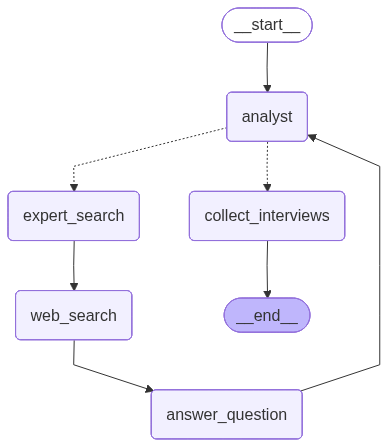

In [17]:
# Annotate every node function !!!

interview_graph = StateGraph(SingleInterviewState)
interview_graph.add_node('analyst',generate_and_ask_question)
interview_graph.add_node('expert_search', expert_search_query)
interview_graph.add_node('web_search',web_search)
interview_graph.add_node('answer_question', answer_question)
interview_graph.add_node('collect_interviews',collect_interviews)

interview_graph.add_edge(START, 'analyst')
interview_graph.add_conditional_edges('analyst', finish_convo, ['collect_interviews','expert_search'])
interview_graph.add_edge('expert_search', 'web_search')
interview_graph.add_edge('web_search', 'answer_question')
interview_graph.add_edge('answer_question', 'analyst')
interview_graph.add_edge('collect_interviews',END)

interview_graph = interview_graph.compile(checkpointer = within_thread_memory)
display(Image(interview_graph.get_graph(xray=1).draw_mermaid_png()))

In [18]:
temp_interview_struct = SingleInterviewState(
    analyst = Analyst_schema(
name = 'Dr. Aisha Patel',
pointers_for_interview = ['Clarify domain scope: RPA, manufacturing automation, and AI-driven decision making.', 'Probe data lineage, governance, and audit trails for automated workflows.', 'Assess deployment maturity from pilot to production and real-world ROI.', 'Explore safety, reliability metrics, and failure modes in automation Pipelines.', 'Investigate integration challenges with legacy systems and vendor interoperability.'],
skills = ['AI automation research', 'RPA', 'MLOps', 'Production deployment', 'Edge AI', 'AI governance', 'Interpretable AI', 'Robotics integration'],
affiliation = 'Professor of Computer Science, AI Automation Lab, XYZ University; Co-founder, AutoAI Labs',
experience = 'Over 12 years researching AI-enabled automation in manufacturing and enterprise workflows. Led multi-disciplinary projects spanning RPA, edge deployment, and governance frameworks. Distinguished across 9 sub-domains including RPA, enterprise automation, MLOps, edge AI, autonomous decision systems, governance, interpretability, robotics integration, and data pipelines.',
responsibility = 'Lead expert interview focusing on the convergence of AI automation tech and enterprise deployment; identify gaps between research and industry practice; produce a landscape report on sub-domains and maturity levels.')
,
conversation_history = [],
web_search_context = [],
sources = [],
expert_search_query = '',
current_question = '',
current_answer = '',
conversation_history_all_agents= [],
sources_all_agents= [])

config = {'configurable': {'thread_id': '1'}}

interview_graph.invoke(temp_interview_struct, config=config)

individual_turns []


Failed to multipart ingest runs: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 

individual_turns ['Thank you for taking time for this interview. From your perspective as a leader at the AI Automation Lab, how would you articulate the maturity model for AI-enabled automation in manufacturing—spanning RPA, automated decision systems, and edge AI—when an organization moves from a pilot to large-scale production? Specifically, how should data lineage, governance, and auditability be designed to support safety, reliability, and compliance; what governance artifacts (policies, metadata schemas, lineage graphs) are non-negotiable for reproducible ROI? What are the most critical risks and failure modes in end-to-end automation pipelines, and how can we detect and mitigate them in real time? Furthermore, what integration challenges typically arise with legacy ERP/SCM systems and with vendor interoperability, and how should enterprises architect interfaces and standards to preserve modularity as they scale? Finally, could you outline a practical, phased roadmap with milesto

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTP

individual_turns ['Thank you for taking time for this interview. From your perspective as a leader at the AI Automation Lab, how would you articulate the maturity model for AI-enabled automation in manufacturing—spanning RPA, automated decision systems, and edge AI—when an organization moves from a pilot to large-scale production? Specifically, how should data lineage, governance, and auditability be designed to support safety, reliability, and compliance; what governance artifacts (policies, metadata schemas, lineage graphs) are non-negotiable for reproducible ROI? What are the most critical risks and failure modes in end-to-end automation pipelines, and how can we detect and mitigate them in real time? Furthermore, what integration challenges typically arise with legacy ERP/SCM systems and with vendor interoperability, and how should enterprises architect interfaces and standards to preserve modularity as they scale? Finally, could you outline a practical, phased roadmap with milesto

...

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTP

individual_turns ['Here is a concise synthesis of the conversation, preserving the core context and details.\n\n- Whole-system maturity and governance frame\n  - The maturity model spans three AI-enabled capabilities—RPA, automated decision systems (ADS), and edge AI—adopted along a ladder from pilot to enterprise-scale. Across all phases, governance, data lineage, and observability are embedded in the operating model, not just the codebase. A phased, governance-driven blueprint is provided to translate pilots into scalable ROI while improving safety and reliability.\n\n- End-to-end data lineage, immutability, and explainability\n  - Architecture spans OT/IT and edge-to-cloud: OT data plane (sensors/PLC/HMI) → edge compute (local feature extraction, inference) → edge-to-cloud transport (robust streaming with canonical schemas) → cloud analytics and feature store → ERP/MES/SCM interfaces. \n  - Key artifacts: immutable raw and curated data lakes, versioned feature stores, tamper-evident

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


{'analyst': Analyst_schema(name='Dr. Aisha Patel', pointers_for_interview=['Clarify domain scope: RPA, manufacturing automation, and AI-driven decision making.', 'Probe data lineage, governance, and audit trails for automated workflows.', 'Assess deployment maturity from pilot to production and real-world ROI.', 'Explore safety, reliability metrics, and failure modes in automation Pipelines.', 'Investigate integration challenges with legacy systems and vendor interoperability.'], skills=['AI automation research', 'RPA', 'MLOps', 'Production deployment', 'Edge AI', 'AI governance', 'Interpretable AI', 'Robotics integration'], affiliation='Professor of Computer Science, AI Automation Lab, XYZ University; Co-founder, AutoAI Labs', experience='Over 12 years researching AI-enabled automation in manufacturing and enterprise workflows. Led multi-disciplinary projects spanning RPA, edge deployment, and governance frameworks. Distinguished across 9 sub-domains including RPA, enterprise automati

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


In [29]:
convo_history = interview_graph.get_state(config=config)[0]['conversation_history']
sources = interview_graph.get_state(config=config)[0]['sources']

Deserializing unregistered type __main__.Analyst_schema from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('__main__', 'Analyst_schema')]


In [61]:
class final_draft_build(BaseModel):
    conversation_history_all_agents: Annotated[list,add]  = Field(default_factory=[])
    sources_all_agents: Annotated[list,add] = Field(default_factory=[])
    user_input_topic: str = Field(description = 'original requirement of the user')
    intro : str = Field(description = 'Intro of the research paper draft by using all the conversation history.')
    body : str 
    final_draft_sources: Annotated[list[str,int],add] = Field(description = """final sources that are used as references to generate the body of the 
    research report""")

    
CREATE_INTRO_PROMPT = """ You are tasked to draw out an introductory statement from this topic:{original_user_requirement}.
The overall context is that multiple AI assistants were generated by the user to research for a topic by conversing with domain experts.
Please just draw an introductory statement based on the topic and below mentioned conversation history of individual AI research 
assistants that has been compiled in one single context and please keep the word length to a maximum of 300 words.
Conversation_history: {convo_hist}

You are not allowed to return empty handed and also you are not allowed to mention phrases similar to 'User had 4 assistants researching for him/her'.
Just write information regarding the topic by using appropriate info from the conversation history!
"""


CREATE_BODY_AND_SOURCES_PROMPT = """ You are tasked to draw out a body for a research paper where you will be provided with an appropriate
introduction statement.

The overall context is that multiple AI assistants were generated by the user to research for a topic by conversing with domain experts.
Based on that we have a conversation history between assistants and experts, sources used by the experts to draw out anwers during interviews
and an introductory statement about the whole paper.

Please draw a body for the research paper based on the given context mentioned in this prompt and below mentioned conversation history of individual AI research 
assistants that has been compiled in one single context and please keep the word length to a maximum of 1000 words.

Introduction: {intro}

Conversation_history: {convo_hist}


You are not allowed to return empty handed and also you are not allowed to mention phrases similar to 'User had 4 assistants researching for him/her'.
Just write information regarding the topic by using appropriate info from the conversation history!

All the sources used throughout different conversations will be provided as well and your responsibility is that when you are drafting 
the body of the paper you are also supposed to mention the resource from which that information has been taken from.
One idea you could use to ease your resource compilation is that every conversation history is sequential in some sense so all the sources
are also nested sequentially with respect to nesting of each individual conversation.

NOTE: Please provide sources as a title reference in the places where used throughout the body along with their integer id,
while drawing out the sources section you are supposed to provide a list of sources in which each source will be a list that contains 
a string at the 0 index (containing the source link) and an integer id at the 1 index (containing the id of the source which will also be mapped in the body as well while referencing).
so essentially the overall sources list become a nested list where main_list--(contains)--> individual lists --(contains)--> source, id.
"""


def create_intro(state: final_draft_build):

    original_user_requirement = state.user_input_topic
    convo_hist = state.conversation_history_all_agents
    print(CREATE_INTRO_PROMPT,original_user_requirement, convo_hist)
    response = model.invoke(CREATE_INTRO_PROMPT.format(convo_hist = convo_hist, original_user_requirement = original_user_requirement))
    return {'intro': response.content}
    
def create_body_and_sources(state: final_draft_build):

    intro = state.intro
    convo_hist = state.conversation_history_all_agents
    response = model.with_structured_output({'body': state.body,
                                            'final_draft_sources': state.final_draft_sources}).with_config(temperature = 0.5).invoke(CREATE_BODY_AND_SOURCES_PROMPT.format(convo_hist = convo_hist, intro = intro))
    
    # We use a model with different temperature to present it more semi-formal writing
    # This might be used as a hyper parameter by user to judge how much formality they want in final report writing.
    return {'body': response.body,
           'final_draft_sources': response.final_draft_sources}

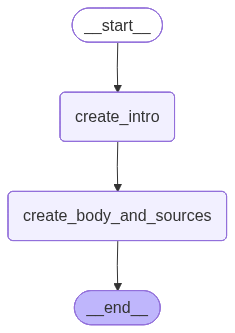

In [62]:
build_final_draft_graph = StateGraph(final_draft_build)

build_final_draft_graph.add_node('create_intro',create_intro)
build_final_draft_graph.add_node('create_body_and_sources',create_body_and_sources)

build_final_draft_graph.add_edge(START,'create_intro')
build_final_draft_graph.add_edge('create_intro','create_body_and_sources')
build_final_draft_graph.add_edge('create_body_and_sources', END)

build_final_draft_graph = build_final_draft_graph.compile(checkpointer = within_thread_memory)
display(Image(build_final_draft_graph.get_graph(xray=1).draw_mermaid_png()))

In [63]:
temp_build_draft_struct =  final_draft_build(conversation_history_all_agents = convo_history,
sources_all_agents = sources,
user_input_topic = 'AI_Automation',
intro = '',
body = '',
final_draft_sources = ['',''])

# final_draft_sources: Annotated[list[str,int],add]

intro_body = build_final_draft_graph.invoke(temp_build_draft_struct, config = config)

 You are tasked to draw out an introductory statement from this topic:{original_user_requirement}.
The overall context is that multiple AI assistants were generated by the user to research for a topic by conversing with domain experts.
Please just draw an introductory statement based on the topic and below mentioned conversation history of individual AI research 
assistants that has been compiled in one single context and please keep the word length to a maximum of 300 words.
Conversation_history: {convo_hist}

You are not allowed to return empty handed and also you are not allowed to mention phrases similar to 'User had 4 assistants researching for him/her'.
Just write information regarding the topic by using appropriate info from the conversation history!
 AI_Automation ['Thank you for taking time for this interview. From your perspective as a Professor of Computer Science in AI Automation and a leader in RPA and manufacturing automation, can you articulate an end-to-end architecture

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


RateLimitError: Error code: 429 - {'error': {'message': 'Request too large for gpt-5-nano in organization org-yaZVQKtAKShIFQ9PJgGFGNRA on tokens per min (TPM): Limit 200000, Requested 316297. The input or output tokens must be reduced in order to run successfully. Visit https://platform.openai.com/account/rate-limits to learn more.', 'type': 'tokens', 'param': None, 'code': 'rate_limit_exceeded'}}

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


In [ ]:
intro = intro_body['intro']
body = intro_body['body']

In [ ]:
print(intro)

In [ ]:
print(body)

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


# Set rate limit issue fallback on the agent as well
# Might need to filter, trim messages right now even before memory thing
# Probably there is a thing with which we can just also make the model sleep for a bit if it hits rate limit or token usage by extracting it after every 3rd model call and store it in a global variable across graph?
# Use exponential backoff, but might need to use a summarization middleware anyways and might need to cut informations as well, can't use a lot of analysts, too much analysts make the conversation history very large, max 4 is allowed
# Do mention these things in the tradeoff section as well,

# is there a way to quantize my tokens or like convert them into some other bit format while model invokation to optimize that?
